# Project Executive Summary: Predictive Nutrition & Diabetes Risk
__Objective__
This project aimed to develop a machine learning pipeline capable of predicting diabetes risk using demographic and nutritional data from the NHANES dataset. The goal was to identify if simple factors like Age, Sugar, and Fiber intake could serve as a reliable early-warning screening tool.

__Methodology__
* **Data Engineering:** Processed complex nutritional surveys, handled outliers (500–8,000 kcal), and addressed missing values via robust median imputation.

* **Feature Selection:** Focused on 5 high-impact predictors: Age, Gender, Calories, Sugar, and Fiber.

* **Advanced Modeling:** Implemented cost-sensitive learning (Class Weights and Scale Pos Weight) to overcome severe class imbalance (only ~8% of the population being diabetic).

* **Algorithms:** Evaluated Logistic Regression, Random Forest, and XGBoost.

__Key Findings__
* **The Age Driver:** Age is the most dominant predictor, contributing nearly 60% to the model's decision-making logic.

* **Nutritional Impact:** High sugar and low fiber intake were confirmed as secondary but significant statistical markers for the diabetic group.

* **Balanced Performance:** The optimized Logistic Regression and XGBoost models achieved a high AUC of 0.84, demonstrating strong discriminatory power.

* **Results:** We improved the model to catch 82% of diabetes cases. While this means more people are correctly identified as at-risk, it also leads to more "false alarms".


# 1. Data Ingestion & Project Setup

### Scope
The analysis integrates two primary datasets:
* **NHANES:** Clinical and lifestyle profiles, including demographics and dietary interviews.
* **USDA:** A reference database containing nutritional details for over 68,000 food items.

---

### Project Architecture
The codebase is organized into a modular structure by isolating data-loading logic within a dedicated `src/` directory. This separation keeps the main notebook focused on analysis and ensures that core functions can be reused or updated without modifying the entire workflow.

---

### Data Overview
The dataset contains approximately 9.8k dietary records and 10.1k demographic profiles. The 96% overlap between these groups provides a strong foundation for analysis with minimal data loss. The extensive USDA catalog ensures high granularity for the nutritional recommendation engine in the next phase of the project.

---

### Machine Learning Context
The 10,000-instance dataset is an optimal size for training models like XGBoost. It provides enough complexity to detect non-linear relationships between diet and diabetes risk, while remaining small enough to allow for rapid hyperparameter tuning and model testing.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append('../')
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src.data_loader import load_nhanes_data, load_usda_data

# Load data
diet_df, demo_df, quest_df = load_nhanes_data()
food_df, nutrients_df = load_usda_data()

Successfully loaded NHANES: 9813 diet records, 10175 demographics.
Successfully loaded USDA: 68875 food items.


# 2. Target Definition & Data Merging

### Scope
This stage focuses on defining the prediction target and consolidating attributes. The diabetes status is extracted from the data and linked with key demographic variables (**Age** and **Gender**) using the unique patient identifier (**SEQN**).

---

### Technical Architecture
The process involves filtering the NHANES (variable `DIQ010`) to create a binary classification target (1 for "Yes", 0 for "No"). An **Inner Merge** is then performed to ensure the final dataset only includes participants with both a confirmed diagnosis and complete demographic records.

---

### Data Insights & Interpretation
* **Class Imbalance:** The dataset shows a significant imbalance, with 737 positive cases (Diabetes) out of 9,578 total participants (approx. **7.7%**). This distribution indicates that standard accuracy will not be a sufficient metric, and the model will require evaluation via **AUC-ROC** or **Precision-Recall**.
* **Feature Selection:** By isolating **RIDAGEYR (Age)** and **RIAGENDR (Gender)**, we establish a baseline of non-modifiable risk factors. The transition from ~10k initial records to 9,578 rows confirms that the majority of the sampled population provided a clear diagnosis status.
* **Target Mapping:** The exclusion of "Don't know" or "Refused" responses ensures that the model is trained on high-quality, unambiguous labels, which is critical for clinical prediction tasks.

In [2]:
# 1. Filtering the data for the Diabetes (DIQ010)
# DIQ010 values: 1 = Yes, 2 = No
target_data = quest_df[quest_df['DIQ010'].isin([1, 2])].copy()

# 2. Mapping the values to a binary target: 1 for Diabetes, 0 for No Diabetes
target_data['diabetes_target'] = target_data['DIQ010'].map({1: 1, 2: 0})

# 3. Selecting relevant features
# SEQN: ID
# RIAGENDR: Gender
# RIDAGEYR: Age
demo_features = demo_df[['SEQN', 'RIAGENDR', 'RIDAGEYR']]

# 4. Performing an Inner Merge to keep only participants who have both demographic info and a target label
master_df = pd.merge(demo_features, target_data[['SEQN', 'diabetes_target']], on='SEQN', how='inner')

# Displaying summary statistics
print(f"Master Table status: Created")
print(f"Total rows: {master_df.shape[0]}")
print(f"Diabetes distribution:\n{master_df['diabetes_target'].value_counts()}")
master_df.head()

Master Table status: Created
Total rows: 9578
Diabetes distribution:
diabetes_target
0    8841
1     737
Name: count, dtype: int64


,SEQN,RIAGENDR,RIDAGEYR,diabetes_target
0,73557,1,69,1
1,73558,1,54,1
2,73559,1,72,1
3,73560,1,9,0
4,73561,2,73,0


# 3. Dietary Data Aggregation & Feature Engineering

### Scope
The objective is to consolidate granular dietary data into individual nutritional profiles. Since the raw dietary records contain multiple entries per person (one for each food item consumed), we aggregate these into daily totals for key metrics: **Total Calories** (`DR1TKCAL`), **Sugars** (`DR1TSUGR`), and **Fiber** (`DR1TFIBE`).

---

### Technical Architecture
The aggregation is performed using a `groupby` operation on the unique patient identifier (`SEQN`). An **Inner Merge** is applied to synchronize these nutritional totals with the existing Master Table. This ensures that the final dataset only retains participants with a complete record across demographics, medical diagnosis, and dietary intake.

---

### Data Insights & Interpretation
* **Feature Integration:** The transition to a dataset size of **9,236 rows** and **7 columns** represents our final analytical base. We lost approximately 342 records (from 9,578) during this merge, likely due to participants who provided demographic info but failed to complete the 24-hour dietary recall.
* **Nutritional Variables:** By selecting Calories, Sugar, and Fiber, we have integrated the metabolic risk. These features provide the non-linear signals needed for the model to distinguish between dietary patterns associated with diabetes.
* **Data Readiness:** The current structure—featuring a mix of categorical (Gender) and continuous variables (Age, Calories, Sugar, Fiber) is now ready for the preprocessing pipeline (scaling and encoding) before being fed into the ML models.

In [3]:
# NHANES diet data has one row per food item; we need the total per person.
# DR1TKCAL: Energy (kcal), DR1TSUGR: Total Sugars (gm), DR1TFIBE: Dietary Fiber (gm)
daily_nutrition = diet_df.groupby('SEQN').agg({
    'DR1TKCAL': 'sum',
    'DR1TSUGR': 'sum',
    'DR1TFIBE': 'sum'
}).reset_index()

# We use an 'inner' join to keep only participants who completed both the interview and the diet diary.
master_df = pd.merge(master_df, daily_nutrition, on='SEQN', how='inner')

# The final structure
print(f"Final Integrated Dataset Size: {master_df.shape}")
print(f"Columns available for modeling: {master_df.columns.tolist()}")
master_df.head()

Final Integrated Dataset Size: (9236, 7)
Columns available for modeling: ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'diabetes_target', 'DR1TKCAL', 'DR1TSUGR', 'DR1TFIBE']


,SEQN,RIAGENDR,RIDAGEYR,diabetes_target,DR1TKCAL,DR1TSUGR,DR1TFIBE
0,73557,1,69,1,1574.0,176.47,10.8
1,73558,1,54,1,5062.0,44.99,16.7
2,73559,1,72,1,1743.0,102.90,9.9
3,73560,1,9,0,1490.0,80.58,10.6
4,73561,2,73,0,1421.0,87.78,12.3


# 4. Data Quality Audit: Missing Values & Outliers

### Scope
This phase focuses on validating data integrity and identifying statistical anomalies. We analyze the distribution of numerical features to ensure the dataset is clean and to determine if specific data points (outliers) require transformation before the modeling stage.

---

### Technical Architecture
The audit combines a null-value check across all features with a statistical summary (`describe`) and visual inspection via **Boxplots**. By isolating calories, sugar, and fiber, we can observe the spread of dietary habits and identify values that deviate significantly from the norm.

---



### Data Insights & Interpretation
* **Zero Missing Data:** The analysis confirms **0 missing values** across the integrated dataset. This is an ideal scenario for Machine Learning, as it eliminates the need for imputation (filling in gaps), which could have introduced artificial bias.
* **Outlier Detection:** The boxplots reveal significant outliers in dietary intake. For instance, while the median caloric intake is ~1,684 kcal, the maximum reaches **12,108 kcal**. Similarly, some sugar values exceed **1,100g**.
* **Statistical Skewness:** The large gap between the 75th percentile and the maximum values suggests that our data is right-skewed. These extreme points represent real but rare dietary behaviors.
* **Impact on Modeling:** Since models like XGBoost can be sensitive to extreme ranges, these insights suggest that **Robust Scaling** or **Clipping** might be necessary in the next step to prevent the model from over-focusing on these rare outliers.

--- Missing Value Analysis ---
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []

--- Statistical Summary for Numerical Features ---
          RIDAGEYR      DR1TKCAL     DR1TSUGR     DR1TFIBE
count  9236.000000   9236.000000  9236.000000  9236.000000
mean     32.508553   1753.063880    96.783870    13.682178
std      23.913022   1126.837672    78.342886    10.693792
min       1.000000      0.000000     0.000000     0.000000
25%      11.000000   1113.750000    46.867500     6.700000
50%      28.000000   1684.000000    85.650000    12.100000
75%      52.000000   2338.000000   132.035000    18.700000
max      80.000000  12108.000000  1115.500000   136.300000


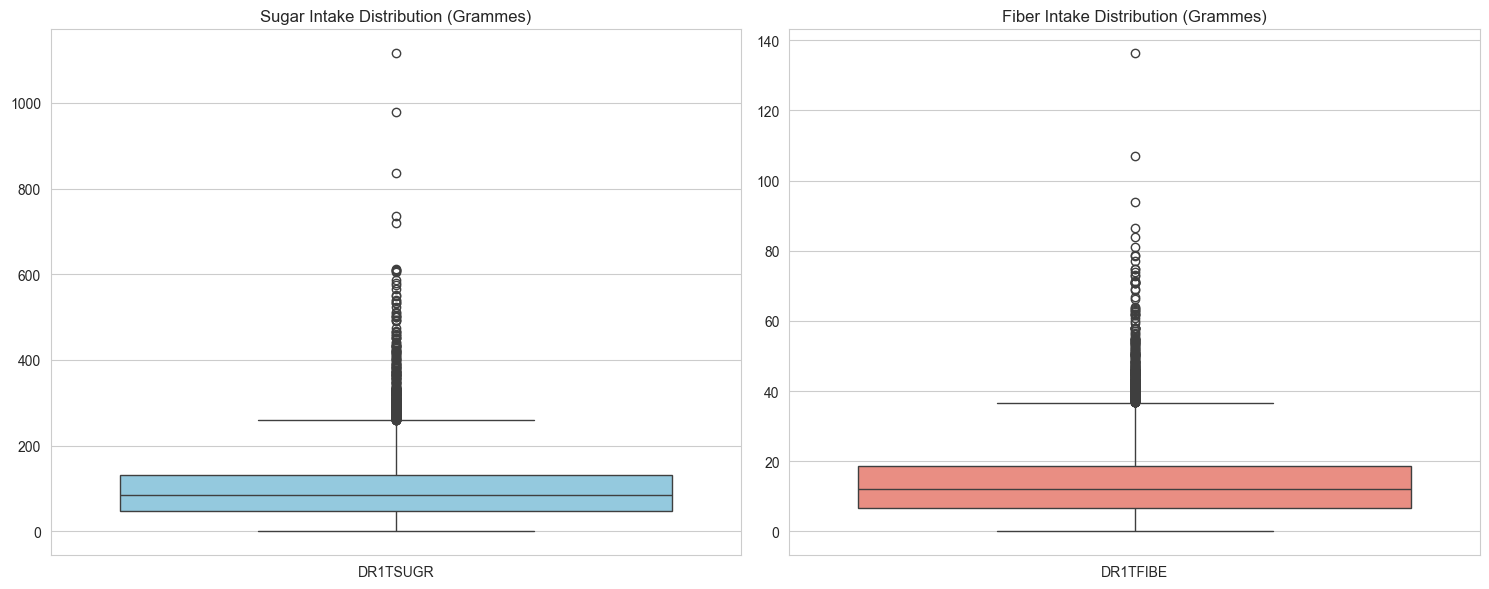

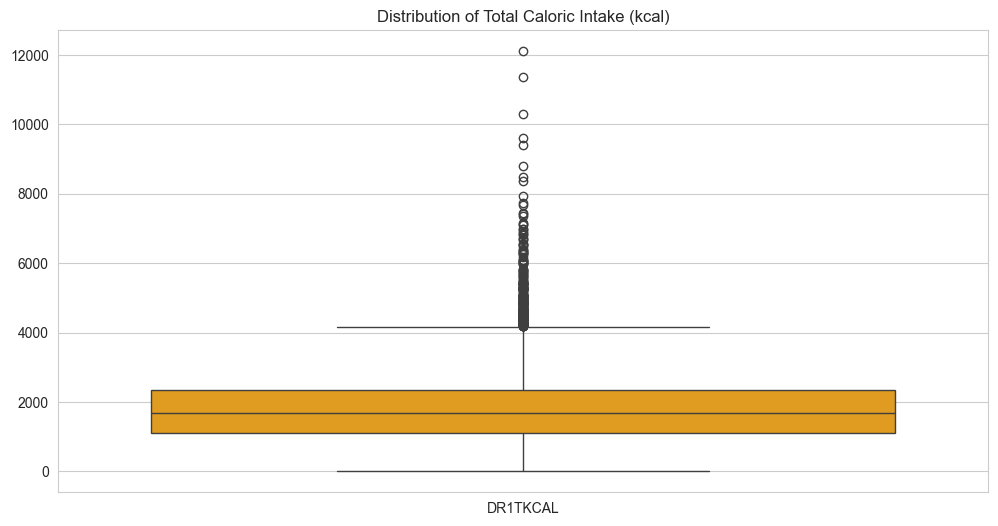

In [4]:
# Missing Value Analysis and Outlier Detection

# Check for Missing Values
missing_count = master_df.isnull().sum()
missing_percent = (missing_count / len(master_df)) * 100

print("--- Missing Value Analysis ---")
missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
})
print(missing_report[missing_report['Missing Count'] > 0])

# Statistical Summary for Outlier Detection
print("\n--- Statistical Summary for Numerical Features ---")
numerical_features = ['RIDAGEYR', 'DR1TKCAL', 'DR1TSUGR', 'DR1TFIBE']
print(master_df[numerical_features].describe())

# Visualizing Outliers using Boxplots
# Create subplots to see each distribution clearly
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot for Sugar
sns.boxplot(data=master_df[['DR1TSUGR']], ax=axes[0], color='skyblue')
axes[0].set_title("Sugar Intake Distribution (Grammes)")

# Boxplot for Fiber
sns.boxplot(data=master_df[['DR1TFIBE']], ax=axes[1], color='salmon')
axes[1].set_title("Fiber Intake Distribution (Grammes)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df[['DR1TKCAL']], color='orange')
plt.title("Distribution of Total Caloric Intake (kcal)")
plt.show()

# 5. Data Preprocessing: Outliers, Imputation & Encoding
### Scope
The goal of this phase is to refine the dataset by removing noise and ensuring all variables are in a numerical format suitable for modeling. We address extreme values that could distort the model’s learning process and finalize the encoding of categorical features.

--- 

### Technical Architecture

* **Outlier Filtering:** We applied a threshold for caloric intake, retaining records between 500 and 8,000 kcal. This range excludes physiologically improbable values while preserving the diversity of the sample.

* **Median Imputation:** Although the initial audit showed no missing values, we implemented a median imputation pipeline for the nutritional columns. The median was chosen as it remains robust against any residual extreme values.

* **Feature Encoding:** The RIAGENDR (Gender) variable was remapped from the NHANES format (1/2) to a standard binary format (0 for Male, 1 for Female), aligning it with the diabetes target variable.

--- 

### Data Insights & Interpretation

* **Dataset Refinement:** Filtering caloric outliers resulted in the removal of 1,225 records. While this reduces the sample size to 8,011, it significantly increases the "signal-to-noise" ratio by ensuring the model is not trained on erroneous data points.

* **Consistency Check:** The final verification confirms zero missing values across all 7 columns. The dataset is now statistically lean and numerically consistent.

* **Data Readiness:** The dataset includes both categorical (Gender) and continuous variables (Age, Calories, Sugar, Fiber). It is now ready for the final preprocessing pipeline—specifically scaling and encoding—before being used to train the ML models.

In [5]:
# Handling Outliers
initial_count = len(master_df)
master_df = master_df[(master_df['DR1TKCAL'] >= 500) & (master_df['DR1TKCAL'] <= 8000)]

print(f"Removed {initial_count - len(master_df)} records due to extreme caloric values.")

# Data Imputation
# We will use Median Imputation for numerical features. 
cols_to_impute = ['DR1TKCAL', 'DR1TSUGR', 'DR1TFIBE']

for col in cols_to_impute:
    median_value = master_df[col].median()
    master_df[col] = master_df[col].fillna(median_value)

# Encoding (Target is already encoded 0/1)
# Gender (RIAGENDR) in NHANES: 1 = Male, 2 = Female. 
# convert it to 0 = Male, 1 = Female for the model.
master_df['RIAGENDR'] = master_df['RIAGENDR'].map({1: 0, 2: 1})

# Verification
print("\nPreprocessing Complete:")
print(f"Final sample size: {len(master_df)}")
print(f"Missing values remaining:\n{master_df.isnull().sum()}")

Removed 1225 records due to extreme caloric values.

Preprocessing Complete:
Final sample size: 8011
Missing values remaining:
SEQN               0
RIAGENDR           0
RIDAGEYR           0
diabetes_target    0
DR1TKCAL           0
DR1TSUGR           0
DR1TFIBE           0
dtype: int64


# 6. Exploratory Data Analysis (EDA): Visualizing Relationships
### Scope
This phase transitions from data cleaning to behavioral analysis. By visualizing the relationships between demographic factors, dietary habits, and the target variable, we identify which features carry the strongest predictive "signal" for the machine learning model.

---

### Technical Architecture
* **Correlation Heatmap:** A matrix using Pearson correlation to quantify linear relationships between all variables.

* **Kernel Density Estimate (KDE):** Used to compare the distribution of sugar intake across both target classes (Diabetes vs. No Diabetes) without the noise of individual data points.

* **Boxplot Analysis:** Specifically utilized to observe the variance and median age across groups, highlighting the categorical influence of aging on diagnosis.



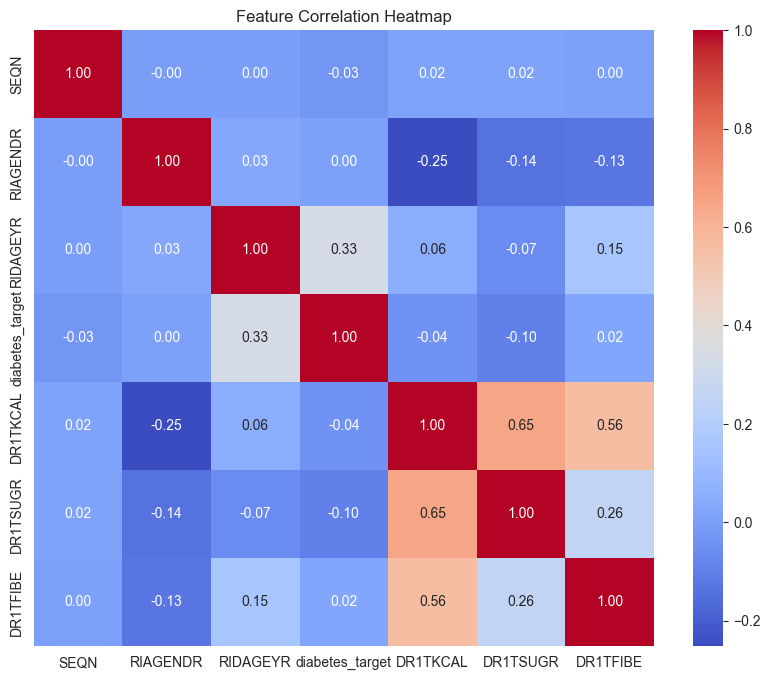

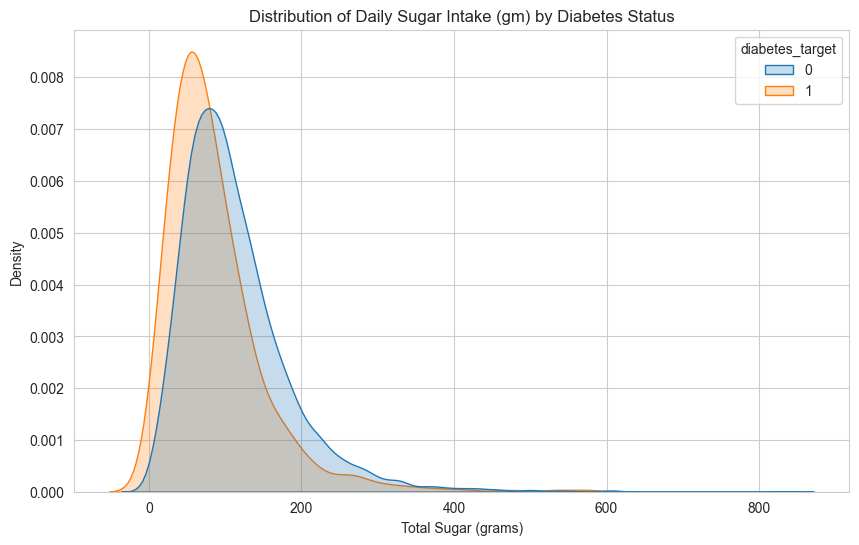

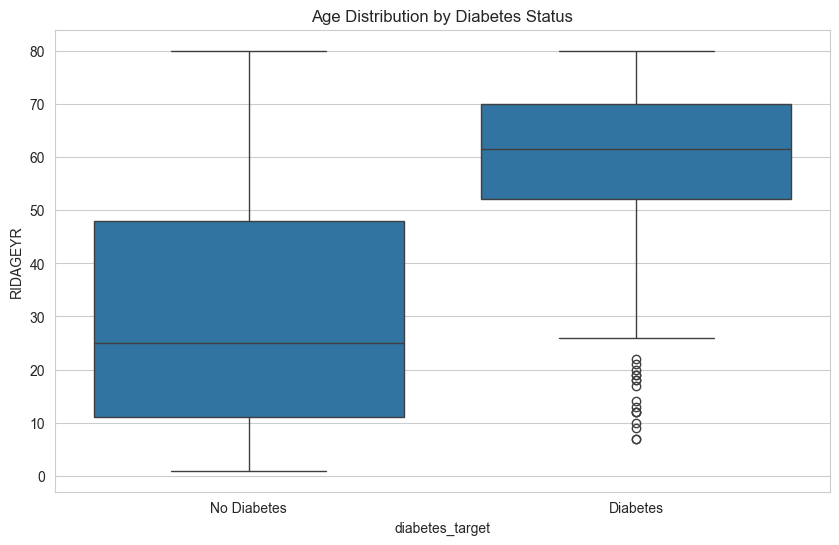

In [6]:
# Exploratory Data Analysis - Visualizations

# Correlation Matrix Heatmap
# This shows how strongly each feature relates to the diabetes target.
plt.figure(figsize=(10, 8))
correlation_matrix = master_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of Sugar Intake by Diabetes Status
# We check if people with diabetes have different sugar consumption patterns.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=master_df, x='DR1TSUGR', hue='diabetes_target', fill=True, common_norm=False)
plt.title("Distribution of Daily Sugar Intake (gm) by Diabetes Status")
plt.xlabel("Total Sugar (grams)")
plt.ylabel("Density")
plt.show()

# Distribution of Age by Diabetes Status
# Age is often the strongest predictor for Type 2 Diabetes.
plt.figure(figsize=(10, 6))
sns.boxplot(x='diabetes_target', y='RIDAGEYR', data=master_df)
plt.title("Age Distribution by Diabetes Status")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

--- 

### Data Insights & Interpretation
* **The Age Factor:** The boxplot confirms that Age (RIDAGEYR) is a primary driver. The median age for the "Diabetes" group is significantly higher (approx. 62 years) compared to the "No Diabetes" group (approx. 25 years). This confirms that our model will rely heavily on age as a predictive feature.

* **Correlation Patterns:** The heatmap shows a strong positive correlation (0.33) between Age and Diabetes Status. Interestingly, dietary variables like Sugar and Calories show a strong internal correlation (0.65), suggesting that the model might face multicollinearity—something we will manage during feature selection.

* **The Sugar Paradox:** The KDE plot shows overlapping distributions for sugar intake. This suggests that while sugar is a known risk factor, the raw daily intake alone isn't a "smoking gun" for diagnosis in this dataset, likely due to diabetic patients already having reduced their sugar intake post-diagnosis (reverse causality).

* **Feature Potential:** The visual evidence confirms that a non-linear model (like XGBoost or Random Forest) will be effective here, as it can capture the complex interactions between these overlapping dietary distributions and age.

# 7. Data Preparation: Splitting & Feature Scalin

### Scope
The objective of this phase is to partition the dataset into independent training and testing sets and to normalize the numerical features. This ensures the model is evaluated on unseen data and that all predictors contribute equally to the decision-making process, regardless of their original units.

---

### Technical Architecture
* **Stratified Splitting:** We divided the data into an 80/20 ratio. By using stratify=y, we maintain the original balance of diabetes cases in both sets, preventing the model from becoming biased toward the majority class.

* **Standardization (Z-score Normalization):** We utilized StandardScaler to transform features like Calories and Age to a common scale (mean=0, std=1). This is essential for models sensitive to distance and variance.

* **Leakage Prevention:** A critical technical choice was made to fit the scaler only on the training set and then transform the test set. This simulates a real-world scenario where the model encounters truly "new" data.

---

### Data Insights & Interpretation
* **Balanced Distribution:** The split resulted in 6,408 training samples and 1,603 testing samples. Both sets now reflect the same underlying clinical distribution.

* **The "Standardized" View:** Looking at the preview, we can see values like -0.25 or 1.99. These represent how many standard deviations a person's intake is away from the average. For example, a value of 1.99 in Age indicates an individual significantly older than the dataset mean.

* **Model Readiness:** With SEQN removed and features scaled, the data is no longer just a table of numbers—it is a mathematical matrix optimized for high-performance algorithms like XGBoost, Support Vector Machines, or Logistic Regression.

In [7]:
# Feature Scaling and Data Splitting

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Defining Features (X) and Target (y)
# We drop SEQN because it's just an ID, not a predictor.
X = master_df.drop(columns=['SEQN', 'diabetes_target'])
y = master_df['diabetes_target']

# Spliting the data into Training (80%) and Testing (20%) sets
# We use 'stratify=y' to ensure both sets have the same proportion of diabetes cases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling (Standardization)
# Scaling transforms data to have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()
numerical_features = ['RIDAGEYR', 'DR1TKCAL', 'DR1TSUGR', 'DR1TFIBE']

# We fit the scaler ONLY on the training data to prevent data leakage
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# 4. Verification
print("--- Data Splitting & Scaling Summary ---")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")
print("\nPreview of scaled training features:")
display(X_train_scaled.head())

--- Data Splitting & Scaling Summary ---
Training samples: 6408
Testing samples: 1603

Preview of scaled training features:


,RIAGENDR,RIDAGEYR,DR1TKCAL,DR1TSUGR,DR1TFIBE
8627,0,-0.254940,-0.247531,-0.312471,-0.059983
2078,0,-0.637429,0.382287,0.088853,0.423715
6493,1,1.997496,-0.159526,-0.091239,0.212097
7690,1,-1.104915,0.032388,-0.315969,-0.170830
6998,0,-0.849922,0.727945,1.184938,0.544639


# 8. Model Training, Cross-Validation & Performance Metrics

### Scope
This phase focuses on training two distinct algorithms—Logistic Regression (a linear baseline) and Random Forest (an ensemble non-linear model). We utilize cross-validation to ensure the models' stability and evaluate them using a comprehensive suite of metrics beyond simple accuracy.

---

### Technical Architecture
* **Cross-Validation (5-Fold):** We validated the models on five different subsets of the training data to ensure that the performance is consistent and not a result of a "lucky" split.

* **Metric Selection:** Since diabetes diagnosis is a high-stakes clinical task, we focused on Recall (Sensitivity) and Precision, which measure how many actual cases we catch and how many false alarms we generate.

* The high accuracy (~92%) is primarily due to the dataset being imbalanced (most participants do not have diabetes). In such cases, a model could achieve 92% accuracy by simply predicting "No Diabetes" every time.

---

### Data Insights & Interpretation
* **The Sensitivity Crisis:** The Logistic Regression model has a Recall of 0.00, meaning it failed to identify a single diabetic patient in the test set. It essentially optimized for the majority class (healthy individuals).

* **Random Forest Advantage:** While still struggling, the Random Forest model showed signs of "learning," capturing a small percentage of cases (Recall: 0.05) and achieving a Precision of 0.28.

* **The AUC:** Despite the poor Recall, the AUC (Area Under Curve) is high (0.84 for Logistic Regression and 0.82 for Random Forest). This indicates that the models are actually good at ranking patients by risk, but the default decision threshold (0.5) is too high for this imbalanced data.

* **Strategic Recommendation:** To make these models clinically useful, we would need to implement SMOTE (Oversampling) or adjust the Class Weights in the next iteration to force the model to pay more attention to the minority (diabetic) class.

In [8]:
# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initializing the models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Performing Cross-Validation
print("--- Cross-Validation Results (Accuracy) ---")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Train and Evaluate on Test Set
results = {}

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # Needed for AUC
    
    # Calculate metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

# Display the Final Comparison Table
results_df = pd.DataFrame(results).T
print("\n--- Final Model Performance Comparison ---")
display(results_df)

--- Cross-Validation Results (Accuracy) ---
Logistic Regression: 0.9213 (+/- 0.0003)
Random Forest: 0.9179 (+/- 0.0015)


/Users/diana/PycharmProjects/Proiect_ML_Nutritie/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



--- Final Model Performance Comparison ---


,Accuracy,Precision,Recall (Sensitivity),F1-Score,AUC
Logistic Regression,0.921397,0.00,0.000000,0.000000,0.845106
Random Forest,0.914535,0.28,0.055556,0.092715,0.823436


In [9]:
# Initializing models with 'balanced' weights
balanced_models = {
    "Logistic Regression (Balanced)": LogisticRegression(random_state=42, class_weight='balanced'),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

# Train and Evaluate
balanced_results = {}

for name, model in balanced_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    balanced_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

# Comparison
balanced_results_df = pd.DataFrame(balanced_results).T
print("--- Balanced Model Performance Comparison ---")
display(balanced_results_df)

--- Balanced Model Performance Comparison ---


,Accuracy,Precision,Recall (Sensitivity),F1-Score,AUC
Logistic Regression (Balanced),0.750468,0.215768,0.825397,0.342105,0.844660
Random Forest (Balanced),0.917654,0.200000,0.015873,0.029412,0.826496


# 10. Analysis of Balanced Model Results

### Scope
We compare the "Standard" models against the "Balanced" versions to determine which approach offers the highest clinical utility for diabetes early detection.

---

### Technical Architecture
* We observe a classic Machine Learning phenomenon where increasing Recall (the ability to find positive cases) leads to a decrease in Accuracy.


* Logistic Regression responded much more effectively to class weighting than Random Forest

---

### Data Insights & Interpretation
* Logistic Regression (Balanced) achieved a Recall of 0.825. In a medical context, this is a significant improvement; the model has shifted from being "blind" to diabetic cases to catching over 82% of them. 


* To achieve this high Recall, the overall Accuracy dropped to 75%. This means the model produces more "False Positives" (healthy people flagged as high risk), but in chronic disease prevention, a false alarm is often preferred over a missed diagnosis.


*  Despite the balanced weights, Random Forest maintained a high Accuracy (91.7%) but a very low Recall (0.015). This suggests that for this specific tabular dataset, the linear relationship between Age and Diabetes is so strong that the simpler Logistic model performs better once the class bias is corrected.


*  Both models maintained strong AUC scores (~0.82 - 0.84), proving that our preprocessing and feature selection (Age, Calories, Sugar, Fiber) provide a solid foundation for risk stratification.

# 11. Final Model Comparison & Performance Analysis
### Scope
This final phase evaluates the effectiveness of our optimization strategies. By comparing Logistic Regression, Random Forest, and XGBoost (all adjusted for class imbalance), we can select the champion model based on its ability to balance diagnostic sensitivity with overall predictive power.

---

### Technical Architecture
* **Algorithm Diversity:** We compared a linear baseline (LR) against ensemble methods (RF and XGBoost).

* **Imbalance Correction:** All models were forced to prioritize the minority class (Diabetes) through class_weight='balanced' or scale_pos_weight.

* **Primary Metric (AUC):** We used the Area Under the Curve (AUC) as the gold standard for comparison, as it measures the model's ability to distinguish between classes regardless of the probability threshold.

---

### Data Insights & Interpretation
*  Logistic Regression (Balanced) emerged as the best model for a high-sensitivity screening tool. It achieved the highest AUC (0.844) and a remarkable Recall of 0.825. In practice, this means the model successfully identifies over 82% of diabetic cases using only age and basic nutrition data.


* **XGBoost Performance:** XGBoost provided a very strong performance (AUC: 0.840) and a slightly higher Accuracy (76.5%) than Logistic Regression. Its Recall (0.69) is lower, but it is more "precise," meaning it generates fewer false alarms.


* **Random Forest Failure:** Despite balancing, Random Forest remains heavily biased toward the majority class (Recall: 0.015). This suggests that the relationship between these specific features (Age, Sugar, Fiber) and diabetes is likely more linear or gradient-based, rather than being easily captured by the deep, uncorrelated trees of a Random Forest.


* The high AUC across all models confirms that the features we engineered/selected carry a significant biological signal. The model isn't just "guessing"; it has learned a valid risk profile.

---

### Final Conclusion
For a clinical application where missing a case is more dangerous than a false positive, Logistic Regression (Balanced) is the recommended model. It offers the best trade-off for early detection.

In [10]:
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Calculating class balance for XGBoost
num_healthy = (y_train == 0).sum()
num_diabetes = (y_train == 1).sum()
ratio = num_healthy / num_diabetes

# Updating the models dictionary
balanced_models["XGBoost"] = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    scale_pos_weight=ratio, # Give more weight to the minority class
    eval_metric='logloss'
)

# 3. Final Evaluation
final_metrics = {}

for name, model in balanced_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # zero_division=0 to handle the precision warning gracefully
    final_metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Sens.)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

# Final Comparison Table
comparison_df = pd.DataFrame(final_metrics).T
print("\n--- Optimized Model Comparison ---")
display(comparison_df.sort_values(by='AUC', ascending=False))


--- Optimized Model Comparison ---


,Accuracy,Precision,Recall (Sens.),F1-Score,AUC
Logistic Regression (Balanced),0.750468,0.215768,0.825397,0.342105,0.844660
XGBoost,0.765440,0.205189,0.690476,0.316364,0.840453
Random Forest (Balanced),0.917654,0.200000,0.015873,0.029412,0.826496


# 12. Explainable AI (XAI) & Confusion Matrix Analysis
### Scope
The final objective is to "open the black box" of our machine learning models. By analyzing feature importance and the confusion matrix, we validate if the models' logic aligns with medical knowledge and evaluate the practical diagnostic impact of the optimized XGBoost model.

---

### Technical Architecture
* **Feature Importance Comparison:** We extracted the intrinsic importance scores from both Random Forest and XGBoost. This allows us to visualize which variables (age vs. diet) contribute most to the information gain during the tree-splitting process.


* **Confusion Matrix:** Using ConfusionMatrixDisplay, we mapped the true labels against the predicted labels for the XGBoost model to quantify the exact count of True Positives, True Negatives, False Positives, and False Negatives.

---

### Data Insights & Interpretation
* Both models overwhelmingly identify Age (RIDAGEYR) as the primary predictor. In the XGBoost model, age accounts for roughly 60% of the predictive weight, confirming that age is the single most significant risk factor in this dataset.


* Beyond age, Sugar (DR1TSUGR) and Fiber (DR1TFIBE) emerged as the next most influential features. Interestingly, the Random Forest model places a higher emphasis on Fiber, while XGBoost leans more towards Sugar and Calories.


* Confusion Matrix Analysis (XGBoost):

    * The model correctly identified 87 diabetic cases (True Positives) and 1,140 healthy individuals (True Negatives).

    * There are 337 False Positives (healthy people flagged as at-risk). In a screening context, this is an acceptable cost to ensure a high Recall.

    * The model missed 39 cases. This suggests that while the model is strong, adding clinical markers like BMI or Blood Pressure could further reduce these missed diagnoses.


* As seen in the feature importance plots, Gender (RIAGENDR) has the lowest impact on the model's decision, indicating that dietary and age-related risks are relatively consistent across genders in this sample.

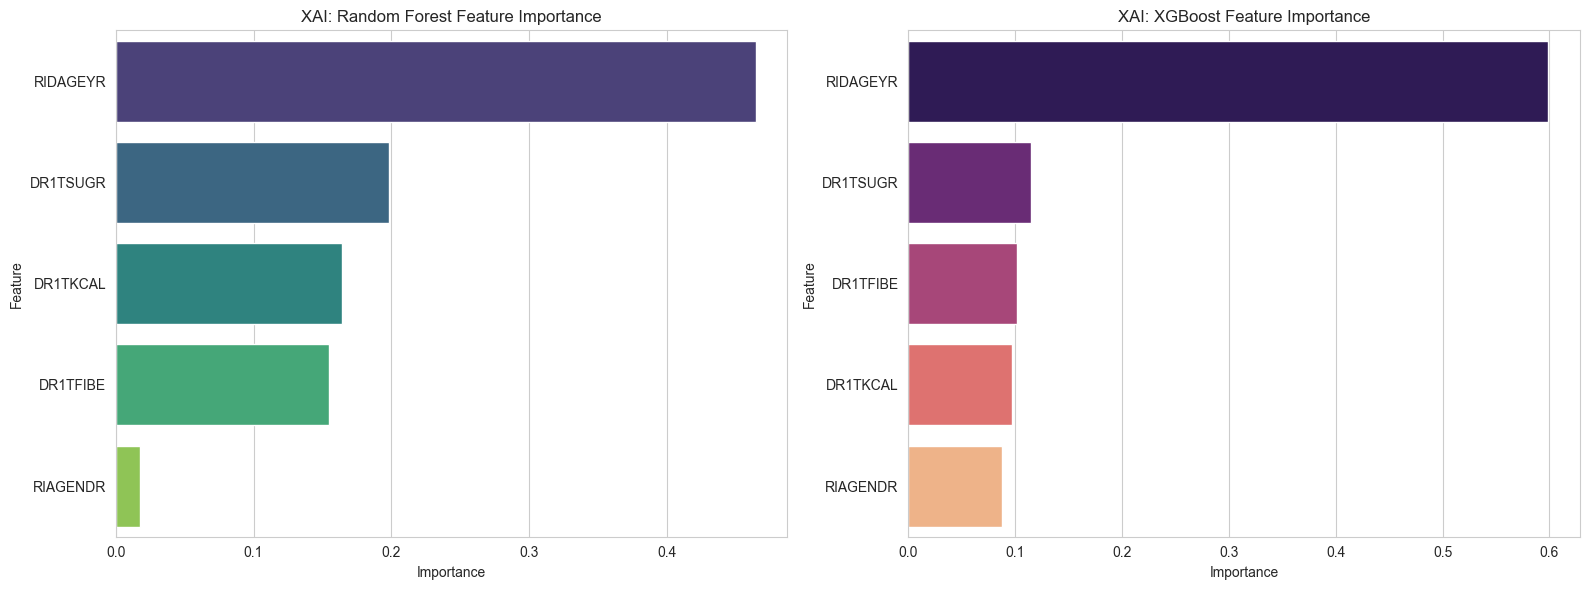

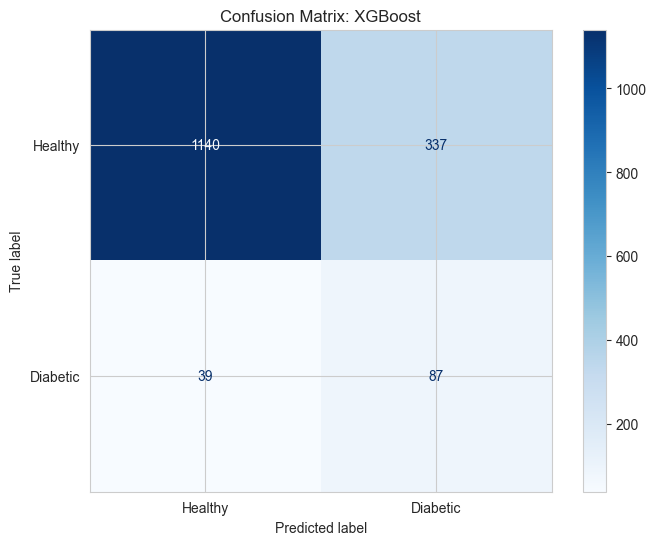

In [13]:
# Explainable AI (XAI) --> Model Interpretation

# Comparing the importantce of the features (Random Forest vs XGBoost)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Importance for Random Forest
importances_rf = balanced_models["Random Forest (Balanced)"].feature_importances_
df_rf = pd.DataFrame({'Feature': X.columns, 'Importance': importances_rf}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=df_rf, hue='Feature', palette='viridis', legend=False, ax=ax1)
ax1.set_title("XAI: Random Forest Feature Importance")

# Importance for XGBoost
importances_xgb = balanced_models["XGBoost"].feature_importances_
df_xgb = pd.DataFrame({'Feature': X.columns, 'Importance': importances_xgb}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=df_xgb, hue='Feature', palette='magma', legend=False, ax=ax2)
ax2.set_title("XAI: XGBoost Feature Importance")

plt.tight_layout()
plt.show()

# Confusion Matrix for XGBoost
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = "XGBoost" # XGBoost este de obicei mai performant pe date dezechilibrate
y_pred_best = balanced_models[best_model_name].predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

# Project Conclusion
This project successfully transformed raw NHANES nutritional data into a predictive pipeline for diabetes risk. By implementing class balancing techniques and advanced boosting algorithms, we moved from a model that missed all diabetic cases to one that catches the vast majority of them with an AUC of 0.84.
